In [76]:
!pip install xgboost scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
from sklearn.model_selection import cross_val_score

pd.set_option('display.max_columns', None)

In [77]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
df.head()

Saving Sample_Dataset.csv to Sample_Dataset (1).csv


,Bid ID,Client,Sector,Budget,Score (%),Outcome,Response Time (hrs),Compliance %,Doc Pages,Gaps Found,Bid Manager,Submission Date,Budget_M,Submission_Month,Submission_Quarter
0,BID-0001,NLC,Construction,PKR 243.5M,81,Loss,87,60,212,6,Bilal Sheikh,2025-12-03,243.5,12,4
1,BID-0002,NESPAK,IT Services,PKR 420.9M,67,Win,36,95,142,3,Faiza Iqbal,2025-06-23,420.9,6,2
2,BID-0003,Jazz,Energy,PKR 110.5M,68,Loss,31,93,212,6,Asif Khan,2025-06-01,110.5,6,2
3,BID-0004,NLC,IT Services,PKR 484.3M,76,Loss,169,58,175,1,Tariq Mehmood,2025-11-27,484.3,11,4
4,BID-0005,FWO,IT Services,PKR 358.4M,59,Loss,164,67,348,2,Nadia Ahmed,2025-01-26,358.4,1,1


In [78]:
df['Budget_M'] = df['Budget'].astype(str).str.replace('PKR', '', regex=False)\
                                          .str.replace('M', '', regex=False)\
                                          .str.strip().astype(float)

df['Submission Date'] = pd.to_datetime(df['Submission Date'])
df['Submission_Month'] = df['Submission Date'].dt.month
df['Submission_Quarter'] = df['Submission Date'].dt.quarter

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Bid ID               500 non-null    object        
 1   Client               500 non-null    object        
 2   Sector               500 non-null    object        
 3   Budget               500 non-null    object        
 4   Score (%)            500 non-null    int64         
 5   Outcome              500 non-null    object        
 6   Response Time (hrs)  500 non-null    int64         
 7   Compliance %         500 non-null    int64         
 8   Doc Pages            500 non-null    int64         
 9   Gaps Found           500 non-null    int64         
 10  Bid Manager          500 non-null    object        
 11  Submission Date      500 non-null    datetime64[ns]
 12  Budget_M             500 non-null    float64       
 13  Submission_Month     500 non-null  

Outcome
Loss    263
Win     237
Name: count, dtype: int64


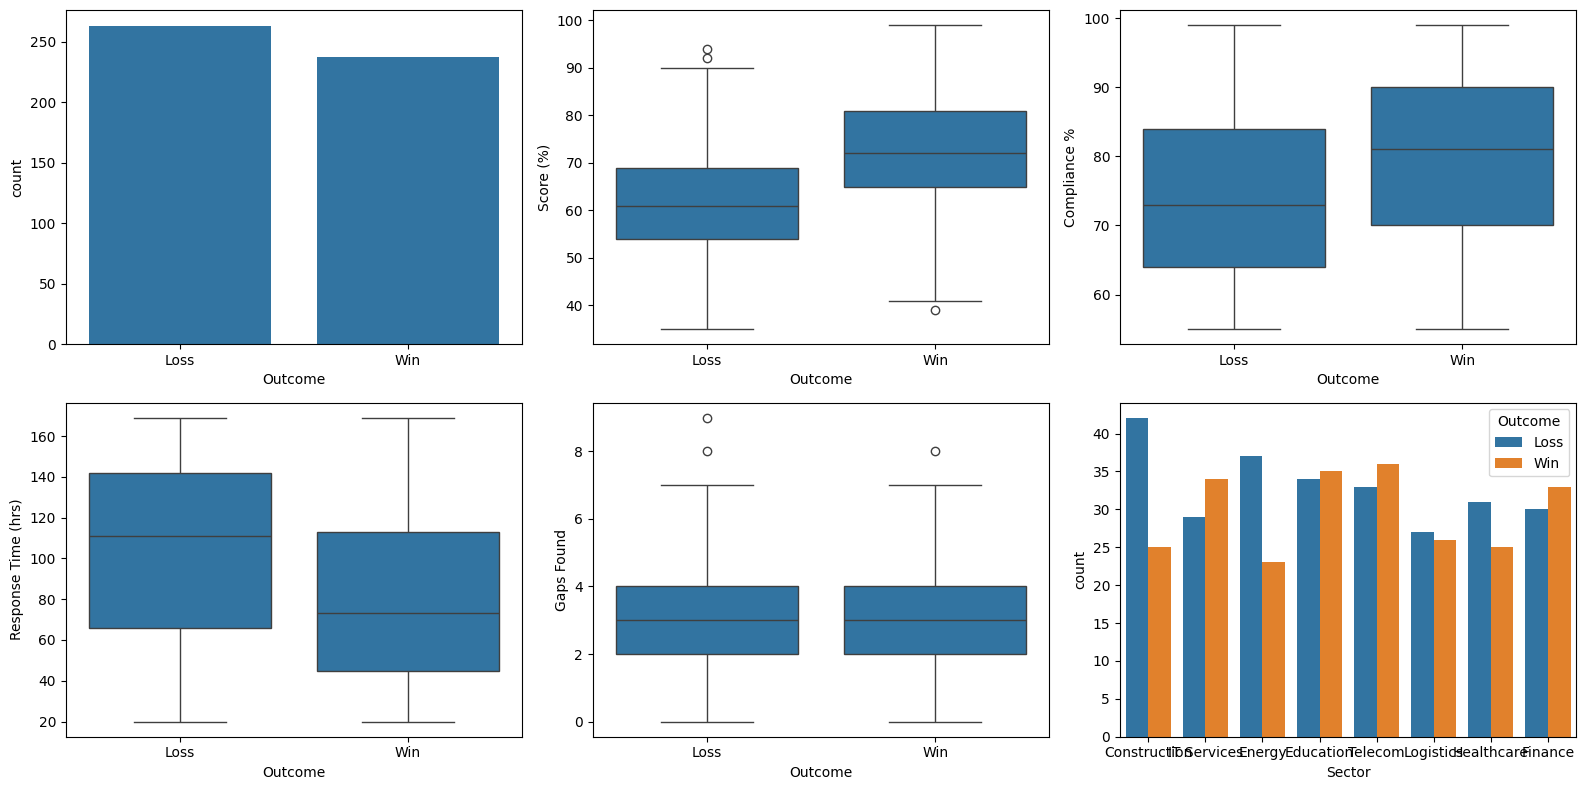

In [79]:
print(df['Outcome'].value_counts())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
sns.countplot(x='Outcome', data=df, ax=axes[0,0])
sns.boxplot(x='Outcome', y='Score (%)', data=df, ax=axes[0,1])
sns.boxplot(x='Outcome', y='Compliance %', data=df, ax=axes[0,2])
sns.boxplot(x='Outcome', y='Response Time (hrs)', data=df, ax=axes[1,0])
sns.boxplot(x='Outcome', y='Gaps Found', data=df, ax=axes[1,1])
sns.countplot(x='Sector', hue='Outcome', data=df, ax=axes[1,2])
plt.tight_layout()
plt.show()

In [80]:
target_col = 'Outcome'

le_target = LabelEncoder()
df['Outcome_enc'] = le_target.fit_transform(df[target_col])  # check classes_ to confirm mapping

drop_cols = ['Bid ID', 'Client', 'Budget', 'Submission Date', 'Outcome',
             'Outcome_enc', 'Bid Manager', 'Score (%)']

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].copy()
y = df['Outcome_enc']

X = pd.get_dummies(X, columns=['Sector'], drop_first=True)
print("Features now used:", X.columns.tolist())


print("Features used:", X.columns.tolist())
print("Target mapping:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

Features now used: ['Response Time (hrs)', 'Compliance %', 'Doc Pages', 'Gaps Found', 'Budget_M', 'Submission_Month', 'Submission_Quarter', 'Sector_Education', 'Sector_Energy', 'Sector_Finance', 'Sector_Healthcare', 'Sector_IT Services', 'Sector_Logistics', 'Sector_Telecom']
Features used: ['Response Time (hrs)', 'Compliance %', 'Doc Pages', 'Gaps Found', 'Budget_M', 'Submission_Month', 'Submission_Quarter', 'Sector_Education', 'Sector_Energy', 'Sector_Finance', 'Sector_Healthcare', 'Sector_IT Services', 'Sector_Logistics', 'Sector_Telecom']
Target mapping: {'Loss': np.int64(0), 'Win': np.int64(1)}


In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(400, 14) (100, 14)


In [82]:
models_params = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'params': {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2']},
        'scaled': True
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        'params': {'max_depth': [3, 5, 7, None], 'min_samples_split': [2, 5, 10]},
        'scaled': False
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'params': {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]},
        'scaled': False
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]},
        'scaled': False
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]},
        'scaled': False
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42, class_weight='balanced'),
        'params': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
        'scaled': True
    }
}

In [83]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_scaled_full = StandardScaler().fit_transform(X)

results = {}
best_estimators = {}

for name, mp in models_params.items():
    Xtr = X_train_scaled if mp['scaled'] else X_train
    Xte = X_test_scaled if mp['scaled'] else X_test
    X_full = X_scaled_full if mp['scaled'] else X

    grid = GridSearchCV(mp['model'], mp['params'], cv=cv, scoring='roc_auc', n_jobs=-1)
    grid.fit(Xtr, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(Xte)
    y_proba = best_model.predict_proba(Xte)[:, 1] if hasattr(best_model, 'predict_proba') else None

    cv_auc_scores = cross_val_score(grid.best_estimator_, X_full, y, cv=cv, scoring='roc_auc')

    results[name] = {
        'Best Params': grid.best_params_,
        'GridSearch CV AUC': grid.best_score_,
        'Full-Data CV AUC (mean)': cv_auc_scores.mean(),
        'Full-Data CV AUC (std)': cv_auc_scores.std(),
        'Holdout Test Accuracy': accuracy_score(y_test, y_pred),
        'Holdout Test Precision': precision_score(y_test, y_pred, zero_division=0),
        'Holdout Test Recall': recall_score(y_test, y_pred, zero_division=0),
        'Holdout Test F1': f1_score(y_test, y_pred, zero_division=0),
        'Predicted class balance': dict(pd.Series(y_pred).value_counts())
    }
    best_estimators[name] = best_model
    print(f"✅ {name} done — Full-Data CV AUC: {cv_auc_scores.mean():.3f} (+/- {cv_auc_scores.std():.3f})")

results_df = pd.DataFrame(results).T.sort_values('Full-Data CV AUC (mean)', ascending=False)
results_df

✅ Logistic Regression done — Full-Data CV AUC: 0.701 (+/- 0.037)
✅ Decision Tree done — Full-Data CV AUC: 0.653 (+/- 0.049)
✅ Random Forest done — Full-Data CV AUC: 0.681 (+/- 0.036)
✅ Gradient Boosting done — Full-Data CV AUC: 0.670 (+/- 0.049)
✅ XGBoost done — Full-Data CV AUC: 0.679 (+/- 0.048)
✅ SVM done — Full-Data CV AUC: 0.698 (+/- 0.043)


,Best Params,GridSearch CV AUC,Full-Data CV AUC (mean),Full-Data CV AUC (std),Holdout Test Accuracy,Holdout Test Precision,Holdout Test Recall,Holdout Test F1,Predicted class balance
Logistic Regression,"{'C': 0.01, 'penalty': 'l2'}",0.692732,0.700951,0.037015,0.62,0.571429,0.765957,0.654545,"{1: 63, 0: 37}"
SVM,"{'C': 0.1, 'kernel': 'linear'}",0.676441,0.698466,0.042851,0.62,0.571429,0.765957,0.654545,"{1: 63, 0: 37}"
Random Forest,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",0.664536,0.681438,0.035692,0.65,0.62,0.659574,0.639175,"{1: 50, 0: 50}"
XGBoost,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.676316,0.679423,0.04847,0.61,0.583333,0.595745,0.589474,"{0: 52, 1: 48}"
Gradient Boosting,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.680514,0.66964,0.04852,0.67,0.64,0.680851,0.659794,"{1: 50, 0: 50}"
Decision Tree,"{'max_depth': 3, 'min_samples_split': 2}",0.648434,0.652514,0.049222,0.61,0.58,0.617021,0.597938,"{1: 50, 0: 50}"


<Figure size 1000x500 with 0 Axes>

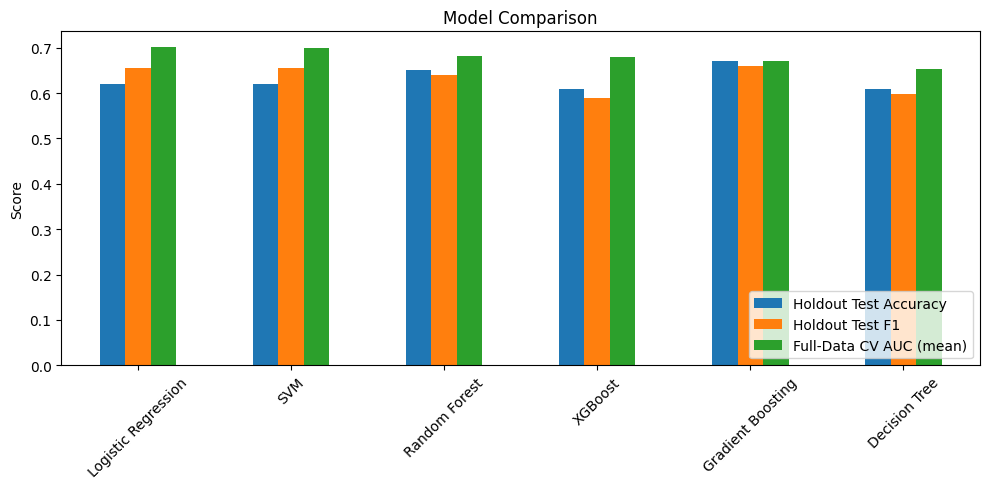

In [84]:
plt.figure(figsize=(10, 5))
results_df[['Holdout Test Accuracy', 'Holdout Test F1', 'Full-Data CV AUC (mean)']].plot(kind='bar', figsize=(10, 5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Best model: Logistic Regression
              precision    recall  f1-score   support

        Loss       0.70      0.49      0.58        53
         Win       0.57      0.77      0.65        47

    accuracy                           0.62       100
   macro avg       0.64      0.63      0.62       100
weighted avg       0.64      0.62      0.61       100



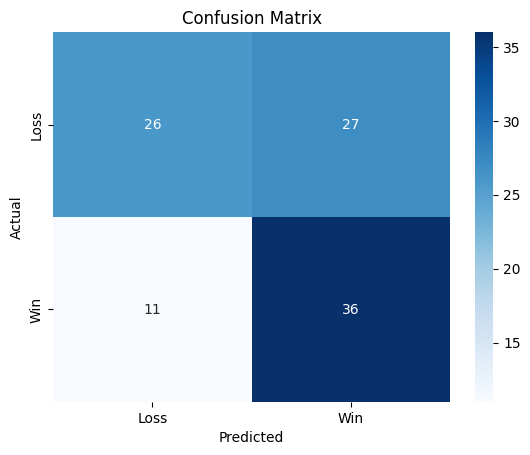

In [85]:
best_model_name = results_df.index[0]
best_model = best_estimators[best_model_name]
print(f"Best model: {best_model_name}")

Xte = X_test_scaled if models_params[best_model_name]['scaled'] else X_test
y_pred = best_model.predict(Xte)

print(classification_report(y_test, y_pred, target_names=le_target.classes_))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    imp.plot(kind='barh', figsize=(8, 6))
    plt.title(f'{best_model_name} — Feature Importance')
    plt.gca().invert_yaxis()
    plt.show()

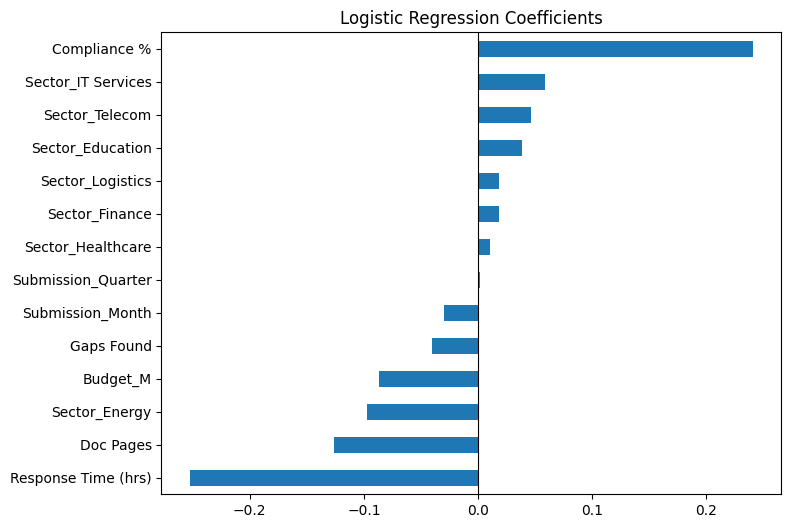

In [86]:
log_reg = best_estimators['Logistic Regression']
coef_df = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()
coef_df.plot(kind='barh', figsize=(8,6))
plt.title('Logistic Regression Coefficients')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

In [87]:
import joblib

final_lr = LogisticRegression(
    **best_estimators['Logistic Regression'].get_params()
)
final_lr.fit(X_scaled_full, y)

joblib.dump({
    'model': final_lr,
    'scaler': scaler,
    'feature_columns': X.columns.tolist(),
    'target_classes': le_target.classes_.tolist()  # e.g. ['Loss', 'Win']
}, 'bid_outcome_model.pkl')

print("Model saved as bid_outcome_model.pkl")

from google.colab import files
files.download

Model saved as bid_outcome_model.pkl


<function google.colab.files.download(filename)>